In [1]:
!pip install torch_geometric
!pip install xarray


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### GAT Prediction

In [3]:
from __future__ import annotations

import json, math, os, re
from pathlib import Path
from typing import List, Tuple, Optional, Sequence

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv
from tqdm.auto import tqdm

__all__ = [
    "homogenise_units",
    "WeatherSequenceDataset",
    "build_global_grid_graph",
    "WeightsBoundedGAT",
    "compute_norm_stats",
    "run_experiment",
]

# --------------------------------------------------------------------------------------
# 1. Unit homogenisation ---------------------------------------------------------------
# --------------------------------------------------------------------------------------
BIG_SCALE = {
    "surface_pressure": 1 / 10,
    "mean_surface_downward_short_wave_radiation_flux": 1 / 10,
    "mean_surface_downward_long_wave_radiation_flux": 1 / 10,
}


def homogenise_units(ds: xr.Dataset) -> xr.Dataset:
    """Standardise units and scales in‑place (returns a copy)."""
    ds = ds.copy()
    if "surface_pressure" in ds:
        ds["surface_pressure"] /= 100.0  # Pa → hPa
    if "total_precipitation" in ds:
        ds["total_precipitation"] = np.log1p(ds["total_precipitation"] * 1000.0)  # m → log‑mm
    for var, fac in BIG_SCALE.items():
        if var in ds:
            ds[var] *= fac
    return ds

# --------------------------------------------------------------------------------------
# 2. Dataset ---------------------------------------------------------------------------
# --------------------------------------------------------------------------------------
VARS = [
    "2m_temperature",
    "specific_humidity",
    "surface_pressure",
    "mean_surface_downward_short_wave_radiation_flux",
    "mean_surface_downward_long_wave_radiation_flux",
    "total_precipitation",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
]  # 8 variables

N_PAST   = 6                           # past steps per sample
N_FEAT   = len(VARS) * N_PAST          # 48 node features
N_TARGET = len(VARS)                   # 8 outputs per node
N_NODES  = 180 * 360                   # global 1° grid


def _open_nc(path: Path) -> xr.Dataset:
    """Lightweight NetCDF loader (SciPy backend avoids HDF‑5 issues on Colab)."""
    return xr.open_dataset(path, engine="scipy")


class WeatherSequenceDataset(Dataset):
    """6‑step‑history → 1‑step target samples spanning whole Earth grid."""

    def __init__(self, files: Sequence[Path], *, mean: np.ndarray | None = None, std: np.ndarray | None = None):
        self.files = list(files)
        self._datasets = [homogenise_units(_open_nc(p)) for p in self.files]
        self.indices: List[Tuple[int, int]] = []  # (file_idx, start_t)
        for i, ds in enumerate(self._datasets):
            t_len = ds.sizes["ten_day_period"]
            self.indices += [(i, t - N_PAST) for t in range(N_PAST, t_len)]
        self.mean, self.std = mean, std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        fidx, t0 = self.indices[idx]
        ds = self._datasets[fidx]

        # Slice 6‑step window + target
        window = ds[VARS].isel(ten_day_period=slice(t0, t0 + N_PAST)).to_array()
# new — use the real dimension names
        window = window.transpose("variable", "latitude", "longitude", "ten_day_period").values
        target = ds[VARS].isel(ten_day_period=t0 + N_PAST)\
                        .to_array()\
                        .transpose("variable", "latitude", "longitude").values

        if self.mean is not None:
            window = (window - self.mean[:, None, None, None]) / (self.std[:, None, None, None] + 1e-6)
            target = (target - self.mean[:, None, None]) / (self.std[:, None, None] + 1e-6)

        # Flatten spatial grid to node dim
        window = window.reshape(len(VARS), N_NODES, N_PAST)
        target = target.reshape(len(VARS), N_NODES)

        x = window.transpose(1, 0, 2).reshape(N_NODES, -1)  # (nodes, 48)
        y = target.transpose(1, 0)                          # (nodes, 8)
        return x.astype(np.float32), y.astype(np.float32)

# --------------------------------------------------------------------------------------
# 3. Graph -----------------------------------------------------------------------------
# --------------------------------------------------------------------------------------

def build_global_grid_graph(n_lat: int = 180, n_lon: int = 360, diag: bool = False):
    """Return `edge_index` tensor for 4‑ or 8‑neighbour grid (periodic in lon)."""
    edges = []
    def node(lat, lon): return lat * n_lon + lon
    nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1)] + ([(-1,-1),(-1,1),(1,-1),(1,1)] if diag else [])
    for lat in range(n_lat):
        for lon in range(n_lon):
            u = node(lat, lon)
            for dlat, dlon in nbrs:
                v = node((lat + dlat) % n_lat, (lon + dlon) % n_lon)
                edges.append((u, v))
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

EDGE_INDEX = build_global_grid_graph()

# --------------------------------------------------------------------------------------
# 4. Model -----------------------------------------------------------------------------
# --------------------------------------------------------------------------------------
class WeightsBoundedGAT(nn.Module):
    def __init__(self, *, in_channels=N_FEAT, hidden=256, heads=4, layers=2, max_norm=1.0, dropout=0.1):
        super().__init__()
        self.max_norm = max_norm
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden, heads=heads, dropout=dropout, concat=True))
        for _ in range(layers - 2):
            self.convs.append(GATConv(hidden * heads, hidden, heads=heads, dropout=dropout, concat=True))
        self.convs.append(GATConv(hidden * heads, N_TARGET, heads=1, concat=False, dropout=dropout))

    def forward(self, x, edge_index=EDGE_INDEX):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
        return x

    def clip(self):
        with torch.no_grad():
            for p in self.parameters():
                if p.ndim >= 2:
                    n = torch.norm(p, p="fro")
                    if n > self.max_norm:
                        p.mul_(self.max_norm / (n + 1e-8))

# --------------------------------------------------------------------------------------
# 5. Stats -----------------------------------------------------------------------------
# --------------------------------------------------------------------------------------

def compute_norm_stats(files: Sequence[Path]):
    """Compute mean/std per variable over *all* time & space (training set)."""
    sums, sqs = np.zeros(len(VARS)), np.zeros(len(VARS))
    count = 0
    for p in tqdm(files, desc="norm stats"):
        ds = homogenise_units(_open_nc(p))
        arr = ds[VARS].to_array().values.reshape(len(VARS), -1)
        sums += arr.sum(axis=1)
        sqs += (arr ** 2).sum(axis=1)
        count += arr.shape[1]
    mean = sums / count
    std  = np.sqrt(np.maximum(sqs / count - mean ** 2, 1e-12))
    return mean, std

# --------------------------------------------------------------------------------------
# 6. Experiment driver ----------------------------------------------------------------
# --------------------------------------------------------------------------------------

def _split_by_year(nc_files: List[Path], *, train_years, val_years, test_years):
    year_re = re.compile(r"(\d{4})")
    buckets = {"train": [], "val": [], "test": []}
    for p in nc_files:
        yr = int(year_re.search(p.stem).group(1))
        if train_years and yr in train_years:
            buckets["train"].append(p)
        elif val_years and yr in val_years:
            buckets["val"].append(p)
        elif test_years and yr in test_years:
            buckets["test"].append(p)
    return buckets["train"], buckets["val"], buckets["test"]
from tqdm.auto import tqdm

def _prepare_batch(x, y, base_edge_index, device):
    if x.dim() == 3:                       # [B , N , F]
        B, N, F = x.shape
        x = x.reshape(B * N, F)
        y = y.reshape(B * N, -1)

        E = base_edge_index.size(1)
        offsets = torch.arange(B, device=device).repeat_interleave(E) * N
        edge_index = base_edge_index.repeat(1, B) + offsets
    else:                                  # already [N , F]
        edge_index = base_edge_index
        y = y.reshape(-1, y.size(-1))
    return x, y, edge_index


def _train_epoch(model, loader, base_edge_index, optim, device, epoch):
    model.train()
    total = 0.0
    prog = tqdm(loader, desc=f"Epoch {epoch:03d} [train]", leave=False)
    for x, y in prog:
        x, y = x.to(device), y.to(device)
        x, y, edge_index = _prepare_batch(x, y, base_edge_index, device)

        pred = model(x, edge_index)
        loss = F.mse_loss(pred, y)

        optim.zero_grad()
        loss.backward()
        optim.step()
        model.clip()

        total += loss.item() * x.size(0)
        prog.set_postfix(loss=loss.item())
    return total / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, base_edge_index, device, epoch, tag="val"):
    model.eval()
    total = 0.0
    prog = tqdm(loader, desc=f"Epoch {epoch:03d} [{tag}]", leave=False)
    for x, y in prog:
        x, y = x.to(device), y.to(device)
        x, y, edge_index = _prepare_batch(x, y, base_edge_index, device)

        loss = F.mse_loss(model(x, edge_index), y)
        total += loss.item() * x.size(0)
        prog.set_postfix(loss=loss.item())
    return total / len(loader.dataset)

def run_experiment(
    data_root: str | os.PathLike,
    *,
    epochs: int = 20,
    batch: int = 4,
    lr: float = 2e-4,
    patience: int = 3,
    train_years: Sequence[int] | None = None,
    val_years: Sequence[int] | None = None,
    test_years: Sequence[int] | None = None,
    num_workers: int = 0,
):
    """End‑to‑end training loop – returns a dict with history & test MSE."""
    data_root = Path(data_root)
    nc_files = sorted(data_root.glob("*.nc"))
    if not nc_files:
        raise FileNotFoundError(f"No NetCDF files in {data_root}")

    # Year‑based split if lists provided, else 70/15/15 chronological
    if any([train_years, val_years, test_years]):
        train_files, val_files, test_files = _split_by_year(nc_files, train_years=train_years,
                                                           val_years=val_years, test_years=test_years)
    else:
        n = len(nc_files)
        train_files, val_files, test_files = nc_files[:int(0.7*n)], nc_files[int(0.7*n):int(0.85*n)], nc_files[int(0.85*n):]

    mean, std = compute_norm_stats(train_files)
    np.save("mean.npy", mean)
    np.save("std.npy",  std)
    train_ds, val_ds, test_ds = (
        WeatherSequenceDataset(lst, mean=mean, std=std) for lst in (train_files, val_files, test_files)
    )
    dl_kwargs = dict(batch_size=batch, num_workers=num_workers)
    train_ld = DataLoader(train_ds, shuffle=True,  **dl_kwargs)
    val_ld   = DataLoader(val_ds,  shuffle=False, **dl_kwargs)
    test_ld  = DataLoader(test_ds, shuffle=False, **dl_kwargs)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = WeightsBoundedGAT().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    best_val, wait = math.inf, patience
    history = {"train": [], "val": []}
    checkpoint_dir = Path("checkpoints")
    checkpoint_dir.mkdir(exist_ok=True)

    best_val, best_epoch, wait = math.inf, -1, patience
    for epoch in range(1, epochs + 1):
        # pass epoch counter ↓↓↓
        t_loss = _train_epoch(model, train_ld, EDGE_INDEX.to(device),
                              optimiser, device, epoch)

        v_loss = _eval_epoch(model, val_ld, EDGE_INDEX.to(device),
                            device, epoch, tag="val")

        history["train"].append(t_loss)
        history["val"].append(v_loss)

        # save checkpoint for *every* epoch
        torch.save(model.state_dict(),
                  checkpoint_dir / f"epoch_{epoch:03d}.pt")

        if v_loss < best_val:
            best_val, best_epoch = v_loss, epoch
            best_state = model.state_dict()
            torch.save(best_state, checkpoint_dir / "best.pt")
            wait = patience
        else:
            wait -= 1
            if wait == 0:
                break
    model.load_state_dict(best_state)
    test_mse = _eval_epoch(model, test_ld, EDGE_INDEX.to(device),
                       device, epoch+1, tag="test")

    print(f"Test MSE: {test_mse:.4e}")
    return {"history": history,
        "test_mse": test_mse,
        "best_epoch": best_epoch}


In [4]:
def train_gat_prediction():
    metrics = run_experiment(
            data_root="/content/drive/MyDrive/ERA5_10day",
            train_years=range(1950,2010 ), val_years=[2011,2012], test_years=[2013],
            epochs=30, batch=4)
    print(metrics["test_mse"])

In [5]:
@torch.no_grad()
def get_predictions(model, loader, base_edge_index, device):
    model.eval()
    all_preds = []
    all_targets = []

    for x, y in tqdm(loader, desc="Collecting predictions", leave=False):
        x, y = x.to(device), y.to(device)
        x, y, edge_index = _prepare_batch(x, y, base_edge_index, device)
        preds = model(x, edge_index)
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

    preds = torch.cat(all_preds, dim=0)     # (total_nodes, num_targets)
    targets = torch.cat(all_targets, dim=0) # (total_nodes, num_targets)
    return preds, targets


def eval_gat_prediction(
    data_root="/content/drive/MyDrive/ERA5_10day",
    test_years=[2013],
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load mean and std
    mean = np.load("mean.npy")
    std = np.load("std.npy")

    # Load all .nc files and split based on year
    data_root = Path(data_root)
    nc_files = sorted(data_root.glob("*.nc"))
    test_files = _split_by_year(nc_files, train_years=[1999], val_years=[2000], test_years=test_years)



    # Build dataset and dataloader
    test_ds = WeatherSequenceDataset(test_files, mean=mean, std=std)
    test_ld = DataLoader(test_ds, batch_size=4, shuffle=False)

    # Load model and weights
    model = WeightsBoundedGAT().to(device)
    checkpoint = torch.load("/content/drive/MyDrive/checkpoint25/best.pt", map_location=device)
    model.load_state_dict(checkpoint)
    criterion = nn.MSELoss()
    # Evaluate


    # Get predictions and targets
    preds, targets = get_predictions(model, test_ld, EDGE_INDEX.to(device), device)

    return preds.numpy(), targets.numpy()

#### Training

In [7]:
# Train the prediction model (next weather state)
train_gat_prediction()

norm stats:   0%|          | 0/60 [00:00<?, ?it/s]

KeyboardInterrupt: 

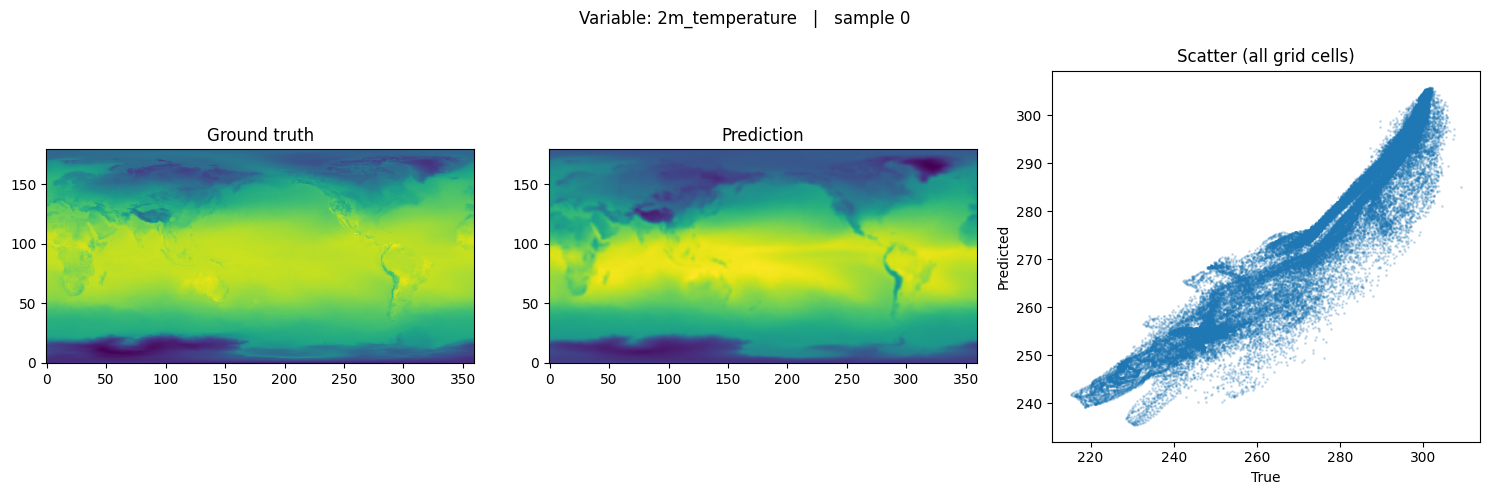

In [8]:
# --------------------------------------------------------------------------------------
# Visualise GT vs prediction on a single batch
# --------------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# --------------- 1. Restore the trained model -----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = WeightsBoundedGAT().to(device)
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/checkpoint25/best.pt", map_location=device))
from pathlib import Path

data_root = Path("/content/drive/MyDrive/ERA5_10day")  # ← change this to your folder path
nc_files = sorted(data_root.glob("*.nc"))

# Split files by year — adjust years to match your dataset
train_files, val_files, test_files = _split_by_year(
    nc_files,
    train_years=range(1990,2010),
    val_years=[2012],
    test_years=[2013]
)
model.eval()
mean = np.load("mean.npy")
std = np.load("std.npy")
test_ds = WeatherSequenceDataset(test_files, mean=mean, std=std)
test_ld = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=0)
# --------------- 2. Get one batch & run inference -------------
with torch.no_grad():
    x_batch, y_batch = next(iter(test_ld))          # shape: [B, N, F]  /  [B, N, 8]
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    x_flat = x_batch.view(-1, N_FEAT)               # [B*N , 48]
    y_flat = y_batch.view(-1, N_TARGET)             # [B*N , 8]
    pred_flat = model(x_flat, EDGE_INDEX.to(device))  # [B*N , 8]

# --------------- 3. Back-transform to physical units ----------
mean_t = torch.tensor(mean, device=device)
std_t  = torch.tensor(std , device=device)
pred_phys = pred_flat * std_t + mean_t              # undo z-score
true_phys = y_flat   * std_t + mean_t

# pick the first sample in the batch and the variable to plot
sample_idx = 0              # 0 … B-1
var_idx    = 0              # 0:"2m_temperature", 1:"specific_humidity", …

n_lat, n_lon = 180, 360
start = sample_idx * N_NODES
end   = start + N_NODES

p_map = pred_phys[start:end, var_idx].cpu().numpy().reshape(n_lat, n_lon)
t_map = true_phys[start:end, var_idx].cpu().numpy().reshape(n_lat, n_lon)

# --------------- 4. Plot --------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(t_map, origin="lower")
axes[0].set_title("Ground truth")

axes[1].imshow(p_map, origin="lower")
axes[1].set_title("Prediction")

axes[2].scatter(
    true_phys[start:end, var_idx].cpu().numpy(),
    pred_phys[start:end, var_idx].cpu().numpy(),
    s=1, alpha=0.2
)
axes[2].set_xlabel("True")
axes[2].set_ylabel("Predicted")
axes[2].set_title("Scatter (all grid cells)")

plt.suptitle(f"Variable: {VARS[var_idx]}   |   sample {sample_idx}")
plt.tight_layout()
plt.show()


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()
sq_err_sum = torch.zeros(len(VARS), device=device)
n_points   = 0

with torch.no_grad():
    for x_batch, y_batch in test_ld:                      # loop over ALL mini-batches
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # reshape to [B*N, ...] and run the network
        x_flat = x_batch.view(-1, N_FEAT)
        y_flat = y_batch.view(-1, N_TARGET)
        pred   = model(x_flat, EDGE_INDEX.to(device))

        # back-transform to physical units
        mean_t = torch.tensor(mean, device=device)
        std_t  = torch.tensor(std , device=device)
        pred_phys = pred   * std_t + mean_t
        true_phys = y_flat * std_t + mean_t

        # accumulate ∑(ŷ−y)² for each variable
        sq_err_sum += torch.sum((pred_phys - true_phys) ** 2, dim=0)
        n_points   += true_phys.shape[0]                  # B * N_NODES

rmse = torch.sqrt(sq_err_sum / n_points)

print("---- Test-set RMSE (physical units) ----")
for var, r in zip(VARS, rmse.cpu().numpy()):
    print(f"{var:45s}: {r:10.3f}")

---- Test-set RMSE (physical units) ----
2m_temperature                               :      5.456
specific_humidity                            :      0.002
surface_pressure                             :      4.512
mean_surface_downward_short_wave_radiation_flux:      7.519
mean_surface_downward_long_wave_radiation_flux:      2.174
total_precipitation                          :      0.375
10m_u_component_of_wind                      :      3.111
10m_v_component_of_wind                      :      2.478


#### Visualizations

### GAT Classification

In [10]:
from __future__ import annotations

import json, math, os, re
from pathlib import Path
from typing import List, Tuple, Optional, Sequence

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from torch_geometric.nn import GATv2Conv
__all__ = [
    "homogenise_units",
    "DroughtSequenceDataset",
    "build_global_grid_graph",
    "GATDroughtModel",
    "compute_norm_stats",
    "run_drought_experiment",
]

# --------------------------------------------------------------------------------------
# 1. Unit homogenisation ---------------------------------------------------------------
# --------------------------------------------------------------------------------------
BIG_SCALE = {
    "surface_pressure": 1 / 10,
    "mean_surface_downward_short_wave_radiation_flux": 1 / 10,
    "mean_surface_downward_long_wave_radiation_flux": 1 / 10,
}


def homogenise_units(ds: xr.Dataset) -> xr.Dataset:
    """Standardise units and scales in‑place (returns a copy)."""
    ds = ds.copy()
    if "surface_pressure" in ds:
        ds["surface_pressure"] /= 100.0  # Pa → hPa
    if "total_precipitation" in ds:
        ds["total_precipitation"] = np.log1p(ds["total_precipitation"] * 1000.0)  # m → log‑mm
    for var, fac in BIG_SCALE.items():
        if var in ds:
            ds[var] *= fac
    return ds

# --------------------------------------------------------------------------------------
# 2. Dataset ---------------------------------------------------------------------------
# --------------------------------------------------------------------------------------
VARS = [
    "2m_temperature",
    "specific_humidity",
    "surface_pressure",
    "mean_surface_downward_short_wave_radiation_flux",
    "mean_surface_downward_long_wave_radiation_flux",
    "total_precipitation",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
]  # 8 variables

N_FEAT   = len(VARS)                   # 8 node features
N_CLASSES = 5                          # drought severity classes (0-4)
N_NODES  = 180 * 360                   # global 1° grid


def _open_nc(path: Path) -> xr.Dataset:
    """Lightweight NetCDF loader (SciPy backend avoids HDF‑5 issues on Colab)."""
    return xr.open_dataset(path, engine="scipy")


class DroughtSequenceDataset(Dataset):
    """Current weather → drought classification for whole Earth grid."""

    def __init__(self, weather_files: Sequence[Path], drought_files: Sequence[Path],
                 *, mean: np.ndarray | None = None, std: np.ndarray | None = None):
        self.weather_files = list(weather_files)
        self.drought_files = list(drought_files)

        # Load weather datasets
        self._weather_datasets = [homogenise_units(_open_nc(p)) for p in self.weather_files]

        # Load drought labels (numpy arrays)
        self._drought_labels = [np.load(p) for p in self.drought_files]

        # Create indices for valid samples
        self.indices: List[Tuple[int, int, int]] = []  # (weather_file_idx, drought_file_idx, time_idx)

        # Match weather and drought files by year
        weather_years = [self._extract_year(p) for p in self.weather_files]
        drought_years = [self._extract_year(p) for p in self.drought_files]

        for w_idx, w_year in enumerate(weather_years):
            if w_year in drought_years:
                d_idx = drought_years.index(w_year)
                w_ds = self._weather_datasets[w_idx]
                t_len = w_ds.sizes["ten_day_period"]
                # Match time steps between weather and drought data
                for t in range(min(t_len, 36)):  # drought labels have 36 time steps
                    self.indices.append((w_idx, d_idx, t))

        self.mean, self.std = mean, std

    def _extract_year(self, path: Path) -> int:
        """Extract year from filename."""
        year_match = re.search(r'(\d{4})', path.stem)
        if year_match:
            return int(year_match.group(1))
        raise ValueError(f"Could not extract year from {path}")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        w_idx, d_idx, t = self.indices[idx]
        weather_ds = self._weather_datasets[w_idx]
        drought_labels = self._drought_labels[d_idx]

        # Get current weather snapshot (single time step)
        current_weather = weather_ds[VARS].isel(ten_day_period=t).to_array()
        current_weather = current_weather.transpose("variable", "latitude", "longitude").values

        # Get drought labels for current time step
        target_drought = drought_labels[t]  # Shape: (180, 360)

        # Normalize weather data
        if self.mean is not None:
            current_weather = (current_weather - self.mean[:, None, None]) / (self.std[:, None, None] + 1e-6)

        # Flatten spatial grid to node dimension
        current_weather = current_weather.reshape(len(VARS), N_NODES)
        target_drought = target_drought.reshape(N_NODES)

        # Prepare features: (nodes, features)
        x = current_weather.transpose(1, 0)  # (nodes, 8)

        # One-hot encode drought labels
        y = np.zeros((N_NODES, N_CLASSES), dtype=np.float32)
        for i, label in enumerate(target_drought):
            if 0 <= label < N_CLASSES:
                y[i, int(label)] = 1.0

        return x.astype(np.float32), y

# --------------------------------------------------------------------------------------
# 3. Graph -----------------------------------------------------------------------------
# --------------------------------------------------------------------------------------

def build_global_grid_graph(n_lat: int = 180, n_lon: int = 360, diag: bool = False):
    """Return `edge_index` tensor for 4‑ or 8‑neighbour grid (periodic in lon)."""
    edges = []
    def node(lat, lon): return lat * n_lon + lon
    nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1)] + ([(-1,-1),(-1,1),(1,-1),(1,1)] if diag else [])
    for lat in range(n_lat):
        for lon in range(n_lon):
            u = node(lat, lon)
            for dlat, dlon in nbrs:
                v = node((lat + dlat) % n_lat, (lon + dlon) % n_lon)
                edges.append((u, v))
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

EDGE_INDEX = build_global_grid_graph()

# --------------------------------------------------------------------------------------
# 4. Model -----------------------------------------------------------------------------
# --------------------------------------------------------------------------------------
class GATDroughtModel(nn.Module):
    def __init__(self, in_channels=N_FEAT, hidden=256, heads=4, layers=3, num_classes=N_CLASSES, dropout=0.1):
        super(GATDroughtModel, self).__init__()
        self.convs = nn.ModuleList()

        # First GATv2 layer
        self.convs.append(GATv2Conv(in_channels, hidden, heads=heads, dropout=dropout))

        # Hidden GATv2 layers
        for _ in range(layers - 2):
            self.convs.append(GATv2Conv(hidden * heads, hidden, heads=heads, dropout=dropout))

        # Final GATv2 layer
        if layers > 1:
            self.convs.append(GATv2Conv(hidden * heads, hidden, heads=1, dropout=dropout))
            final_dim = hidden
        else:
            final_dim = hidden * heads

        # MLP for final classification
        self.mlp = nn.Sequential(
            nn.Linear(final_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, edge_index=EDGE_INDEX):
        # Apply GATv2 convolutions
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:  # Don't apply activation after last conv
                x = F.elu(x)

        # Final classification through MLP
        x = self.mlp(x)
        return x  # Return logits for CrossEntropyLoss

# --------------------------------------------------------------------------------------
# 5. Stats -----------------------------------------------------------------------------
# --------------------------------------------------------------------------------------

def compute_norm_stats(weather_files: Sequence[Path]):
    """Compute mean/std per variable over *all* time & space (training set)."""
    sums, sqs = np.zeros(len(VARS)), np.zeros(len(VARS))
    count = 0
    for p in tqdm(weather_files, desc="norm stats"):
        ds = homogenise_units(_open_nc(p))
        arr = ds[VARS].to_array().values.reshape(len(VARS), -1)
        sums += arr.sum(axis=1)
        sqs += (arr ** 2).sum(axis=1)
        count += arr.shape[1]
    mean = sums / count
    std  = np.sqrt(np.maximum(sqs / count - mean ** 2, 1e-12))
    return mean, std

# --------------------------------------------------------------------------------------
# 6. Experiment driver ----------------------------------------------------------------
# --------------------------------------------------------------------------------------

def _split_by_year(files: List[Path], *, train_years, val_years, test_years):
    """Split files by year."""
    year_re = re.compile(r"(\d{4})")
    buckets = {"train": [], "val": [], "test": []}
    for p in files:
        yr_match = year_re.search(p.stem)
        if yr_match:
            yr = int(yr_match.group(1))
            if train_years and yr in train_years:
                buckets["train"].append(p)
            elif val_years and yr in val_years:
                buckets["val"].append(p)
            elif test_years and yr in test_years:
                buckets["test"].append(p)
    return buckets["train"], buckets["val"], buckets["test"]


def _prepare_batch(x, y, base_edge_index, device):
    """Prepare batch for graph processing."""
    if x.dim() == 3:                       # [B, N, F]
        B, N, F = x.shape
        x = x.reshape(B * N, F)
        y = y.reshape(B * N, -1)

        E = base_edge_index.size(1)
        offsets = torch.arange(B, device=device).repeat_interleave(E) * N
        edge_index = base_edge_index.repeat(1, B) + offsets
    else:                                  # already [N, F]
        edge_index = base_edge_index
        y = y.reshape(-1, y.size(-1))
    return x, y, edge_index

def _train_epoch(model, loader, base_edge_index, optim, device, epoch, criterion):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    prog = tqdm(loader, desc=f"Epoch {epoch:03d} [train]", leave=False)
    for x, y in prog:
        x, y = x.to(device), y.to(device)
        x, y_onehot, edge_index = _prepare_batch(x, y, base_edge_index, device)

        # Convert one-hot to class indices for CrossEntropyLoss
        y_class = torch.argmax(y_onehot, dim=1)

        pred = model(x, edge_index)
        loss = criterion(pred, y_class)

        optim.zero_grad()
        loss.backward()
        optim.step()

        # Store predictions and targets for metrics
        pred_class = torch.argmax(pred, dim=1)
        all_preds.extend(pred_class.cpu().numpy())
        all_targets.extend(y_class.cpu().numpy())

        total_loss += loss.item() * x.size(0)

        # Update the progress bar without overwriting previous prints
        prog.set_postfix(loss=loss.item(), refresh=True)

    # Calculate accuracy during training
    accuracy = np.mean(np.array(all_preds) == np.array(all_targets))

    return total_loss / len(loader.dataset), accuracy




@torch.no_grad()
@torch.no_grad()
def _eval_epoch(model, loader, base_edge_index, device, epoch, criterion, tag="val"):
    """Evaluate for one epoch."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    prog = tqdm(loader, desc=f"Epoch {epoch:03d} [{tag}]", leave=False)
    for x, y in prog:
        x, y = x.to(device), y.to(device)
        x, y_onehot, edge_index = _prepare_batch(x, y, base_edge_index, device)

        # Convert one-hot to class indices
        y_class = torch.argmax(y_onehot, dim=1)

        pred = model(x, edge_index)
        loss = F.cross_entropy(pred, y_class)

        # Store predictions and targets for metrics
        pred_class = torch.argmax(pred, dim=1)
        all_preds.extend(pred_class.cpu().numpy())
        all_targets.extend(y_class.cpu().numpy())

        total_loss += loss.item() * x.size(0)
        prog.set_postfix(loss=loss.item(), refresh=True)

    # Calculate accuracy at the end of the evaluation
    accuracy = np.mean(np.array(all_preds) == np.array(all_targets))

    # Calculate other metrics only for the test set
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)

    return total_loss / len(loader.dataset), accuracy, f1_macro, f1_weighted, precision, recall



def run_drought_experiment(
    weather_data_root: str | os.PathLike,
    drought_data_root: str | os.PathLike,
    *,
    epochs: int = 20,
    batch: int = 4,
    lr: float = 2e-4,
    patience: int = 5,
    train_years: Sequence[int] | None = None,
    val_years: Sequence[int] | None = None,
    test_years: Sequence[int] | None = None,
    num_workers: int = 0,
):
    """End‑to‑end drought classification training loop."""
    weather_root = Path(weather_data_root)
    drought_root = Path(drought_data_root)

    # Get weather and drought files
    weather_files = sorted(weather_root.glob("*.nc"))
    drought_files = sorted(drought_root.glob("*.npy"))

    if not weather_files:
        raise FileNotFoundError(f"No NetCDF files in {weather_root}")
    if not drought_files:
        raise FileNotFoundError(f"No NPY files in {drought_root}")

    # Year‑based split if lists provided, else 70/15/15 chronological
    if any([train_years, val_years, test_years]):
        train_weather, val_weather, test_weather = _split_by_year(
            weather_files, train_years=train_years, val_years=val_years, test_years=test_years)
        train_drought, val_drought, test_drought = _split_by_year(
            drought_files, train_years=train_years, val_years=val_years, test_years=test_years)
    else:
        n_w, n_d = len(weather_files), len(drought_files)
        train_weather = weather_files[:int(0.7*n_w)]
        val_weather = weather_files[int(0.7*n_w):int(0.85*n_w)]
        test_weather = weather_files[int(0.85*n_w):]

        train_drought = drought_files[:int(0.7*n_d)]
        val_drought = drought_files[int(0.7*n_d):int(0.85*n_d)]
        test_drought = drought_files[int(0.85*n_d):]

    # Compute normalization stats from weather training data
    mean, std = compute_norm_stats(train_weather)
    np.save("drought_mean.npy", mean)
    np.save("drought_std.npy", std)

    # Create datasets
    train_ds = DroughtSequenceDataset(train_weather, train_drought, mean=mean, std=std)
    val_ds = DroughtSequenceDataset(val_weather, val_drought, mean=mean, std=std)
    test_ds = DroughtSequenceDataset(test_weather, test_drought, mean=mean, std=std)
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Create data loaders
    dl_kwargs = dict(batch_size=batch, num_workers=num_workers)
    train_ld = DataLoader(train_ds, shuffle=True, **dl_kwargs)
    val_ld = DataLoader(val_ds, shuffle=False, **dl_kwargs)
    test_ld = DataLoader(test_ds, shuffle=False, **dl_kwargs)

    criterion     = nn.CrossEntropyLoss()

    # Setup model and training
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = GATDroughtModel().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)  # weight decay here

    # Training loop
    best_val_f1, best_epoch, wait = 0.0, -1, patience
    history = {
        "train_loss": [], "train_acc": [], "train_f1_macro": [], "train_f1_weighted": [],
        "train_precision": [], "train_recall": [],
        "val_loss": [], "val_acc": [], "val_f1_macro": [], "val_f1_weighted": [],
        "val_precision": [], "val_recall": []
    }

    checkpoint_dir = Path("/content/drive/MyDrive/drought_checkpoints")
    checkpoint_dir.mkdir(exist_ok=True)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = _train_epoch(model, train_ld, EDGE_INDEX.to(device),
                                             optimiser, device, epoch,criterion)
        val_loss, val_acc, val_f1_macro, val_f1_weighted, val_precision, val_recall = _eval_epoch(
            model, val_ld, EDGE_INDEX.to(device), device, epoch, criterion, tag="val")

        # Store history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1_macro"].append(val_f1_macro)
        history["val_f1_weighted"].append(val_f1_weighted)
        history["val_precision"].append(val_precision)
        history["val_recall"].append(val_recall)

        print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")
        print(f"             Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1_weighted:.4f}")

        # Save checkpoint
        torch.save(model.state_dict(), checkpoint_dir / f"epoch_{epoch:03d}.pt")

        # Early stopping based on validation F1 score
        if val_f1_weighted > best_val_f1:
            best_val_f1, best_epoch = val_f1_weighted, epoch
            best_state = model.state_dict()
            torch.save(best_state, checkpoint_dir / "best.pt")
            wait = patience
        else:
            wait -= 1
            if wait == 0:
                print(f"Early stopping at epoch {epoch}")
                break

    # Load best model and evaluate on test set
    model.load_state_dict(best_state)
    test_loss, test_acc, test_f1_macro, test_f1_weighted, test_precision, test_recall = _eval_epoch(
        model, test_ld, EDGE_INDEX.to(device), device, epochs + 1, criterion, tag="test")

    print(f"\nFinal Test Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1 (Macro): {test_f1_macro:.4f}")
    print(f"Test F1 (Weighted): {test_f1_weighted:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")

    return {
        "history": history,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1_macro,
        "test_f1_weighted": test_f1_weighted,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1
    }


In [11]:

def train_gat_classification():
    results = run_drought_experiment(
        weather_data_root="/content/drive/MyDrive/ERA5_10day",
        drought_data_root="/content/drive/MyDrive/spi_label",
        epochs=20,
        batch=2,
        lr=1e-4,
        train_years=range(1991, 2019),
        val_years=[2019,2020],
        test_years=[2021]
    )
    print(f"Final test accuracy: {results['test_accuracy']:.4f}")

In [12]:
def eval_gat_classification(
    x: torch.Tensor,
    edge_index: torch.Tensor,
    model_path: str = "/content/drive/MyDrive/drought_checkpoints/best.pt",
):
    """
    Load best GAT model and run inference on given features and edge_index.
    Assumes x is (N, 8) node features, and edge_index is (2, E).
    """
    # Load normalization stats

    # Load model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = GATDroughtModel()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    # Move inputs to device
    x = x.to(device)
    edge_index = edge_index.to(device)

    # Run inference
    with torch.no_grad():
        logits = model(x, edge_index)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    return preds  # shape (N,)

#### Training

In [ ]:

# Train the drought classification model
train_gat_classification()


#### Visualization

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def visualize_predictions(model, test_loader, device, edge_index, class_names=None):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Visualizing predictions"):
            x, y = x.to(device), y.to(device)
            x, y_onehot, edge_index_batched = _prepare_batch(x, y, edge_index, device)
            y_class = torch.argmax(y_onehot, dim=1)

            logits = model(x, edge_index_batched)
            pred_class = torch.argmax(logits, dim=1)

            all_preds.extend(pred_class.cpu().numpy())
            all_targets.extend(y_class.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds, labels=list(range(N_CLASSES)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names or [f"Class {i}" for i in range(N_CLASSES)])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title("Confusion Matrix: Predicted vs Actual Drought Classes")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    return cm


In [15]:
# Re-import if needed
from torch_geometric.nn import GATv2Conv
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Recreate the model exactly as it was during training
model = GATDroughtModel(
    in_channels=N_FEAT,
    hidden=256,
    heads=4,
    layers=3,
    num_classes=N_CLASSES,
    dropout=0.1
).to(device)

# Load best checkpoint
model.load_state_dict(torch.load("/content/drive/MyDrive/drought_checkpoints/best.pt"))
model.eval()


GATDroughtModel(
  (convs): ModuleList(
    (0): GATv2Conv(8, 256, heads=4)
    (1): GATv2Conv(1024, 256, heads=4)
    (2): GATv2Conv(1024, 256, heads=1)
  )
  (mlp): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [16]:
from pathlib import Path
import numpy as np

# Load normalization stats
mean = np.load("drought_mean.npy")
std = np.load("drought_std.npy")

# Define paths
weather_data_root = Path("/content/drive/MyDrive/ERA5_10day")
drought_data_root = Path("/content/drive/MyDrive/spi_label")

# Collect test files (make sure they match what was used during training)
test_years = [2021]

def _split_by_year(files, *, train_years, val_years, test_years):
    year_re = re.compile(r"(\d{4})")
    buckets = {"train": [], "val": [], "test": []}
    for p in files:
        match = year_re.search(p.stem)
        if match:
            year = int(match.group(1))
            if test_years and year in test_years:
                buckets["test"].append(p)
    return buckets["test"]

# Get test files
weather_test_files = _split_by_year(sorted(weather_data_root.glob("*.nc")),
                                    train_years=None, val_years=None, test_years=test_years)
drought_test_files = _split_by_year(sorted(drought_data_root.glob("*.npy")),
                                    train_years=None, val_years=None, test_years=test_years)

# Create dataset and loader
test_ds = DroughtSequenceDataset(weather_test_files, drought_test_files, mean=mean, std=std)
from torch.utils.data import DataLoader
test_ld = DataLoader(test_ds, batch_size=2, shuffle=False)


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_drought_map(pred, actual, title_suffix="", cmap="YlOrRd", save_path=None):
    """
    Plot predicted and actual drought maps side-by-side for 180×360 grid.
    """
    # Reshape to lat-lon
    pred_map = pred.reshape(180, 360)
    actual_map = actual.reshape(180, 360)

    fig, axs = plt.subplots(1, 2, figsize=(18, 5))

    im0 = axs[0].imshow(actual_map, cmap=cmap, vmin=0, vmax=4)
    axs[0].set_title(f"Actual Drought Classes {title_suffix}")
    axs[0].axis('off')
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

    im1 = axs[1].imshow(pred_map, cmap=cmap, vmin=0, vmax=4)
    axs[1].set_title(f"Predicted Drought Classes {title_suffix}")
    axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    plt.suptitle("Drought Classification on Global Grid", fontsize=16)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()


In [ ]:
# Get one batch from test loader
x_batch, y_batch = next(iter(test_ld))

# Move to device
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

# Prepare batch
x_flat, y_flat, edge_index_batch = _prepare_batch(x_batch, y_batch, EDGE_INDEX.to(device),device)

# Get predictions
with torch.no_grad():
    logits = model(x_flat, edge_index_batch)
    pred_classes = torch.argmax(logits, dim=1)
    true_classes = torch.argmax(y_flat, dim=1)

# Plot first sample (if batched)
N = N_NODES
pred_sample = pred_classes[:N].cpu().numpy()
true_sample = true_classes[:N].cpu().numpy()

# Visualize
plot_drought_map(pred_sample, true_sample, title_suffix="(Sample 1)")


### Combining the models

In [ ]:
# Run prediction model on 2013 data
preds, _ = eval_gat_prediction(
    data_root="/content/drive/MyDrive/ERA5_10day",


    test_years=[2013]
)

# Convert prediction (N, 8) per node to torch tensor
x_pred = torch.tensor(preds, dtype=torch.float32)

# Run classification on predicted weather features
drought_preds = eval_gat_classification(x_pred, EDGE_INDEX)

# drought_preds shape: (N_NODES,)
print("Drought class predictions:", np.unique(drought_preds, return_counts=True))


In [ ]:

# Load ground truth drought labels (flattened)
true_labels = np.load("/content/drive/MyDrive/spi_label/2013.npy")[6].reshape(-1)  # time step 6 to align

from sklearn.metrics import classification_report
print(classification_report(true_labels, drought_preds, zero_division=0))